In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anujshah0311/healthcare-dataset-stroke-data/healthcare-dataset-stroke-data.csv


# Stroke Prediction: Risk Factors and a Screening Model

**Question:** Which patient factors are linked to stroke, and can a simple model flag high-risk patients?

**Data:** Healthcare Stroke Dataset by Anuj Shah on Kaggle (5,110 patients, 11 features, target = `stroke`).

**Approach:** clean the data, explore it with charts, then train and compare two models, with the focus on catching stroke cases (recall), not accuracy.

## 1. Load the data

First I list the files in the Kaggle input folder to find the dataset path, then load the CSV with pandas.

In [23]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/anujshah0311/healthcare-dataset-stroke-data/healthcare-dataset-stroke-data.csv


Now I load the CSV into a pandas DataFrame and look at the first 5 rows. Each row is one patient, and `stroke` (0 = no, 1 = yes) is the target I want to predict.

In [24]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/anujshah0311/healthcare-dataset-stroke-data/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Checking the size and column types. The data has 5,110 rows and 12 columns. Only `bmi` has missing values (201 of them), and every other column is complete.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Checking how many patients had a stroke. Only 249 of 5,110 patients (about 4.9%) had a stroke, so the data is heavily **imbalanced**. This matters later: a model that always predicts "no stroke" would be about 95% accurate and still useless, so I judge the models on recall and ROC-AUC instead of accuracy.

In [26]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

## 2. Exploring the data

First chart: stroke vs no stroke. The tall "no stroke" bar and the tiny "stroke" bar show the class imbalance clearly.

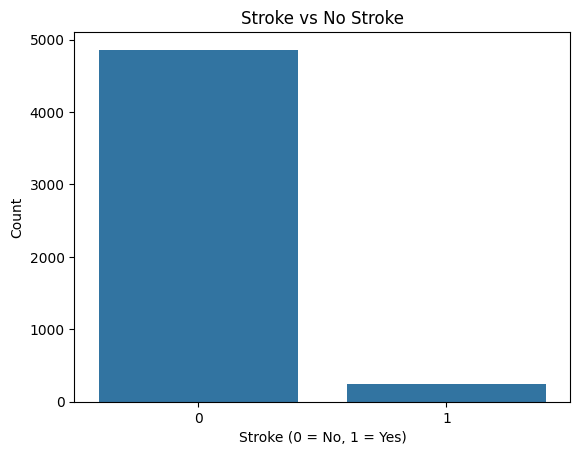

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="stroke", data=df)
plt.title("Stroke vs No Stroke")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Stroke rate by age group. The rate climbs steadily with age, from almost 0% in the youngest group to about 20% in the 76+ group. Age is clearly a strong risk factor.

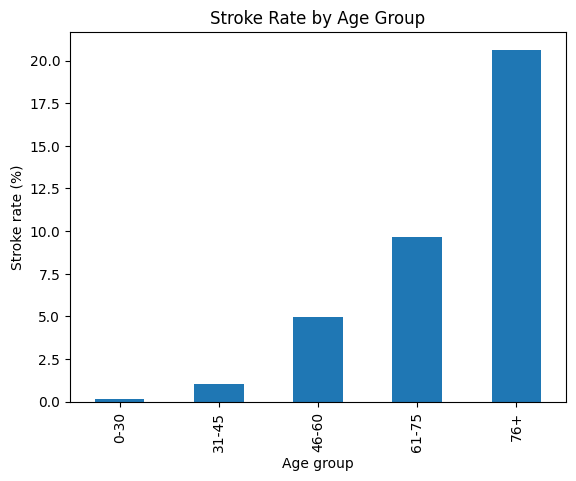

In [28]:
df["age_group"] = pd.cut(df["age"], bins=[0, 30, 45, 60, 75, 100],
                         labels=["0-30", "31-45", "46-60", "61-75", "76+"])

rate = df.groupby("age_group", observed=True)["stroke"].mean() * 100

rate.plot(kind="bar")
plt.title("Stroke Rate by Age Group")
plt.xlabel("Age group")
plt.ylabel("Stroke rate (%)")
plt.show()

Stroke rate by hypertension and heart disease. Patients with hypertension had a stroke rate of about 13% against about 4% for those without. For heart disease it was about 17% against about 4%. Both are clear risk factors.

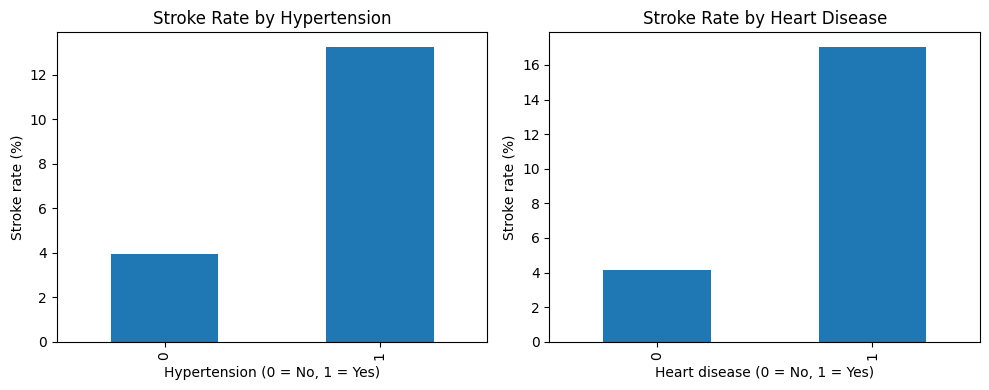

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

(df.groupby("hypertension")["stroke"].mean() * 100).plot(kind="bar", ax=axes[0])
axes[0].set_title("Stroke Rate by Hypertension")
axes[0].set_xlabel("Hypertension (0 = No, 1 = Yes)")
axes[0].set_ylabel("Stroke rate (%)")

(df.groupby("heart_disease")["stroke"].mean() * 100).plot(kind="bar", ax=axes[1])
axes[1].set_title("Stroke Rate by Heart Disease")
axes[1].set_xlabel("Heart disease (0 = No, 1 = Yes)")
axes[1].set_ylabel("Stroke rate (%)")

plt.tight_layout()
plt.show()

Glucose level and BMI by stroke. Stroke patients show a much wider spread of glucose levels, with many at high values (up to about 200). BMI looks almost the same in both groups, so it does not separate stroke from no stroke much on its own.

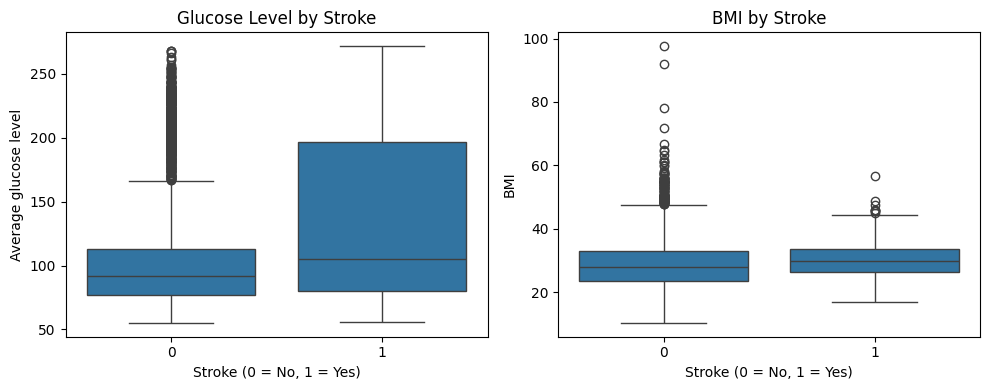

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(x="stroke", y="avg_glucose_level", data=df, ax=axes[0])
axes[0].set_title("Glucose Level by Stroke")
axes[0].set_xlabel("Stroke (0 = No, 1 = Yes)")
axes[0].set_ylabel("Average glucose level")

sns.boxplot(x="stroke", y="bmi", data=df, ax=axes[1])
axes[1].set_title("BMI by Stroke")
axes[1].set_xlabel("Stroke (0 = No, 1 = Yes)")
axes[1].set_ylabel("BMI")

plt.tight_layout()
plt.show()

Correlation heatmap of the numeric columns. Age has the strongest link to stroke (0.25). Hypertension, heart disease and glucose are each about 0.13, and BMI is almost nothing (0.04). All the values are low because stroke is rare, but the order matches the charts above.

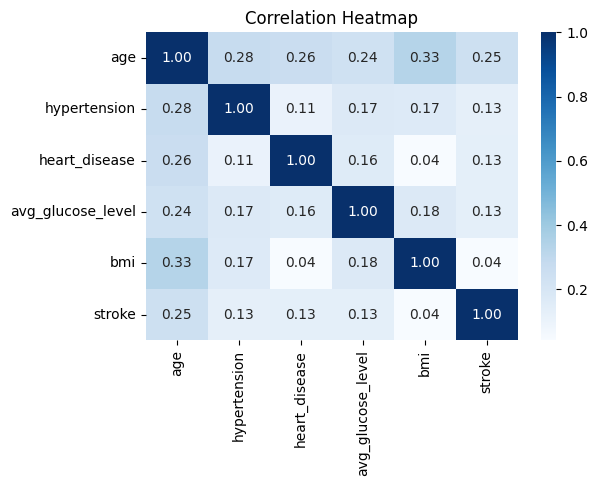

In [31]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]].corr(),
            annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

train_test_split

In [32]:
from sklearn.model_selection import train_test_split

## 3. Cleaning and splitting the data

Cleaning steps:
- Dropped the `id` column, which is useless for prediction.
- Removed the single row with gender "Other", which is too rare to learn from.
- Filled the 201 missing `bmi` values with the median BMI.

Then I split the data 80% training and 20% testing. I used `stratify=y` so both sets keep the same share of stroke cases (about 4.9%).

In [33]:
df = df.drop(columns="id", errors="ignore")
df = df[df["gender"] != "Other"]
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

X = df.drop(columns=["stroke", "age_group"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(df.isnull().sum().sum())
print(X_train.shape, X_test.shape)

0
(4087, 10) (1022, 10)


## 4. Modelling

**Preprocessing:** text columns (like `work_type`) are turned into numbers with one-hot encoding, and number columns are scaled with `StandardScaler`, so the model can use all of them.

**Model:** logistic regression with `class_weight="balanced"`, so the model pays more attention to the rare stroke cases instead of ignoring them.

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

pre = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first"), cat_cols),
    ("num", StandardScaler(), num_cols)
])

model = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))
])

model.fit(X_train, y_train)
print("Model trained")

Model trained


## 5. Evaluating the model

I test on the 1,022 patients the model has never seen. Accuracy would be misleading because the data is imbalanced, so I look at recall and precision for stroke cases, plus ROC-AUC.

- **Recall 0.80:** the model caught 40 of the 50 real stroke cases.
- **Precision 0.13:** only 13% of the flagged patients really had a stroke, so there are many false alarms. This is the usual trade-off when strokes are this rare.
- **ROC-AUC 0.84:** the model separates stroke from no stroke fairly well.

In [35]:
from sklearn.metrics import classification_report, roc_auc_score

pred = model.predict(X_test)
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

ROC-AUC: 0.8392798353909465


Confusion matrix for the logistic regression:

- **714** healthy patients correctly cleared
- **258** healthy patients wrongly flagged (false alarms)
- **10** strokes missed
- **40** strokes caught

For a screening tool, missing only 10 of 50 strokes matters more than the false alarms, which is why I prefer this model to one with higher accuracy.

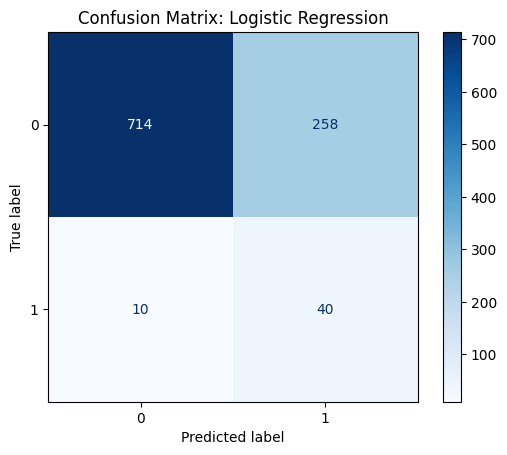

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

## 6. Comparing with a random forest

To check whether a more complex model does better, I trained a random forest with the same preprocessing.

- **Recall 0.00:** it missed all 50 strokes and basically predicted "no stroke" for everyone.
- **Accuracy 0.95** looks great, but it is the imbalance trap: predicting "no" for everyone scores 95% here and catches nobody.
- **ROC-AUC 0.78** is lower than the logistic regression's 0.84.

Logistic regression is therefore my final model.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC: 0.7795473251028806


## 7. Which factors matter most?

The logistic regression coefficients show which factors push the predicted stroke risk up or down.

- **Age** is by far the strongest factor.
- **Glucose level and hypertension** raise the predicted risk.
- **Smoking** has a small effect.
- **BMI** has almost no effect on its own.
- The `work_type_children` bar is a side effect of age: children are so young that the age term already pushes their risk very low, and this bar corrects for it. It is not a medical finding.

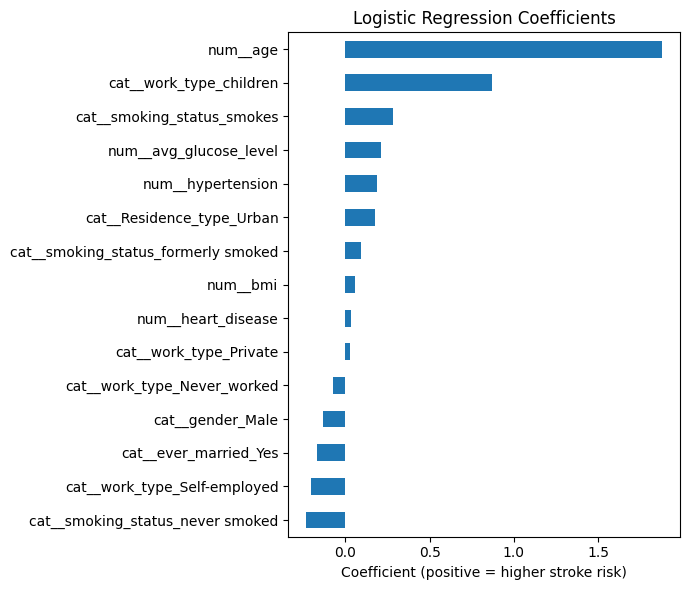

In [38]:
names = model.named_steps["pre"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

importance = pd.Series(coefs, index=names).sort_values()
importance.plot(kind="barh", figsize=(7, 6))
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient (positive = higher stroke risk)")
plt.tight_layout()
plt.show()

## 8. Conclusion

- **Main risk factors:** age is by far the strongest factor. Hypertension, heart disease and high glucose also go with a higher stroke rate. BMI shows almost no link on its own.
- **Best model:** logistic regression caught 40 of 50 strokes (recall 0.80, ROC-AUC 0.84). The random forest missed all of them despite 95% accuracy, so accuracy was misleading here.

## Limitations

- The data is heavily imbalanced (about 4.9% strokes), and precision is low (0.13), so the model gives many false alarms.
- 201 missing BMI values were filled with the median, and "Unknown" in smoking status was kept as its own category.
- I used one train/test split and did not tune the model or the decision threshold.
- The `work_type_children` coefficient reflects age, not a medical finding.
- This is a learning project. The model is not for clinical use.

**Data source:** Healthcare Stroke Dataset by Anuj Shah, Kaggle.